In [13]:
import json
import numpy as np
import cv2
import os

# --- Adım 1: Gerekli Ayarları Yapılandırma ---

# COCO anotasyon dosyanızın yolu
JSON_FILE_PATH = './data/courtv2-3/valid/_annotations.coco.json'

# Oluşturulacak maskelerin kaydedileceği klasör
OUTPUT_MASKS_DIR = 'masks'

# Klasör yoksa oluşturalım
if not os.path.exists(OUTPUT_MASKS_DIR):
    os.makedirs(OUTPUT_MASKS_DIR)
    print(f"'{OUTPUT_MASKS_DIR}' klasörü oluşturuldu.")

# --- Adım 2: COCO Verisini Yükleme ve Hazırlama ---

with open(JSON_FILE_PATH, 'r') as f:
    coco_data = json.load(f)

# Kategorileri daha kolay erişim için bir sözlüğe dönüştürelim (id -> name)
categories = {cat['id']: cat['name'] for cat in coco_data['categories']}

# Anotasyonları resim ID'lerine göre gruplayalım
annotations_by_image_id = {}
for ann in coco_data['annotations']:
    image_id = ann['image_id']
    if image_id not in annotations_by_image_id:
        annotations_by_image_id[image_id] = []
    annotations_by_image_id[image_id].append(ann)

# --- Adım 3: Sınıf Kimlikleri ve Hiyerarşiyi Belirleme ---

# Oluşturacağımız maske için yeni ve basit sınıf kimlikleri
mask_class_ids = {
    "ARKA_PLAN": 0,
    "UC_SAYI_BOLGESI": 1,
    "IKI_SAYI_BOLGESI": 2,
    "UC_SANIYE_ALANI": 3
}

# COCO kategori adlarını bizim yeni maske kimliklerimize eşleyelim
category_to_mask_id = {
    'court': mask_class_ids['UC_SAYI_BOLGESI'],
    'two_point_area': mask_class_ids['IKI_SAYI_BOLGESI'],
    'three_second_area': mask_class_ids['UC_SANIYE_ALANI']
}

# BOYAMA SIRASI (HİYERARŞİ): En dıştan en içe doğru
drawing_order = ['court', 'two_point_area', 'three_second_area']


# --- Adım 4: Maske Oluşturma Fonksiyonu ---
# Bu fonksiyon bir önceki cevap ile aynıdır.
def create_mask_from_coco(image_info, annotations):
    height, width = image_info['height'], image_info['width']
    mask = np.full((height, width), mask_class_ids["ARKA_PLAN"], dtype=np.uint8)

    for category_name in drawing_order:
        mask_id_to_draw = category_to_mask_id.get(category_name)
        if mask_id_to_draw is None:
            continue # Eğer eşleşme yoksa bu kategoriyi atla

        for ann in annotations:
            ann_category_name = categories[ann['category_id']]
            if ann_category_name == category_name:
                segmentation = ann['segmentation'][0]
                polygon = np.array(segmentation, dtype=np.int32).reshape((-1, 1, 2))
                cv2.fillPoly(mask, [polygon], mask_id_to_draw)
    return mask

# --- Adım 5: Tüm Görüntüler İçin Maskeleri Oluşturma ve Kaydetme ---

total_images = len(coco_data['images'])
print(f"\nToplam {total_images} adet görüntü için maske oluşturuluyor...")

for i, image_info in enumerate(coco_data['images']):
    image_id = image_info['id']
    annotations = annotations_by_image_id.get(image_id, [])

    if not annotations:
        print(f"({i+1}/{total_images}) - UYARI: '{image_info['file_name']}' için anotasyon bulunamadı, atlanıyor.")
        continue

    # Maskeyi oluştur
    final_mask = create_mask_from_coco(image_info, annotations)

    # Orijinal dosya adından yeni maske dosya adını oluştur
    # Örn: 'ornek.jpg' -> 'ornek.png'
    base_filename = os.path.splitext(image_info['file_name'])[0]
    output_filename = f"{base_filename}.png"
    output_path = os.path.join(OUTPUT_MASKS_DIR, output_filename)

    # Maskeyi PNG olarak kaydet
    cv2.imwrite(output_path, final_mask)
    
    # İlerlemeyi göstermek için her 10 resimde bir mesaj yazdır
    if (i + 1) % 10 == 0 or (i + 1) == total_images:
        print(f"({i+1}/{total_images}) Maske kaydedildi: {output_path}")

print(f"\nİşlem tamamlandı! Tüm maskeler '{OUTPUT_MASKS_DIR}' klasörüne kaydedildi.")

'masks' klasörü oluşturuldu.

Toplam 255 adet görüntü için maske oluşturuluyor...
(10/255) Maske kaydedildi: masks\Olympiacos-Piraeus-Anadolu-Efes-Istanbul-_-Round-5-Highlights-_-2023-24-Turkish-Airlines-EuroLeague-mp4_frame_1375_jpg.rf.dba849f02e4d46929e31b178f3ba8f1c.png
(20/255) Maske kaydedildi: masks\hoolonVSjerusalem-mp4_frame_27600_jpg.rf.e795cd4f65f938d9f14f238096124d5f.png
(30/255) Maske kaydedildi: masks\videokai_rapaaport_hapoel_tlv0034_png.rf.f4d6cca458bd55e5216420a6a73b7eaf.png
(40/255) Maske kaydedildi: masks\hapeltelavivVSjerusalem-mp4_frame_4050_jpg.rf.f95e1162e6e3c0b6f305f9402b59b4fd.png
(50/255) Maske kaydedildi: masks\videohapeol_tlv_nes_ziona_highlights0042_png.rf.0544f011fd35ccae3dd444e97d7850b2.png
(60/255) Maske kaydedildi: masks\ASVELVirtus_-Round-5-Highlights-_-2023-24-Turkish-Airlines-EuroLeague-mp4_frame_2925_jpg.rf.1141035fe03f689c1ab4b7a0b3c17503.png
(70/255) Maske kaydedildi: masks\hoolonVSjerusalem-mp4_frame_11400_jpg.rf.13c9a9336c4f4368dff58babdcfae0cd.p

'./data/courtv2-3/test/masks' klasöründen 3 adet rastgele maske görselleştiriliyor...


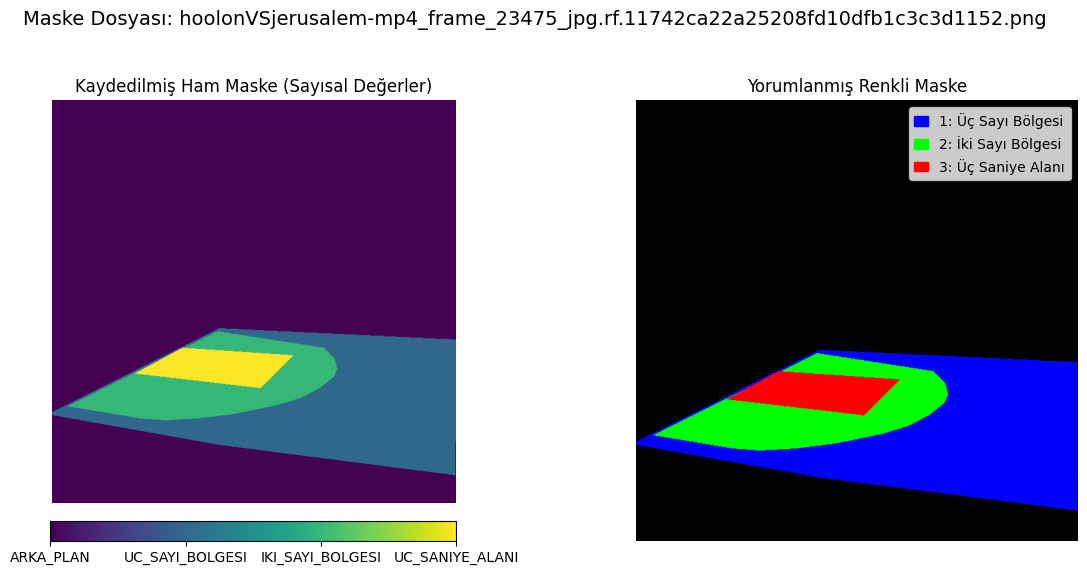

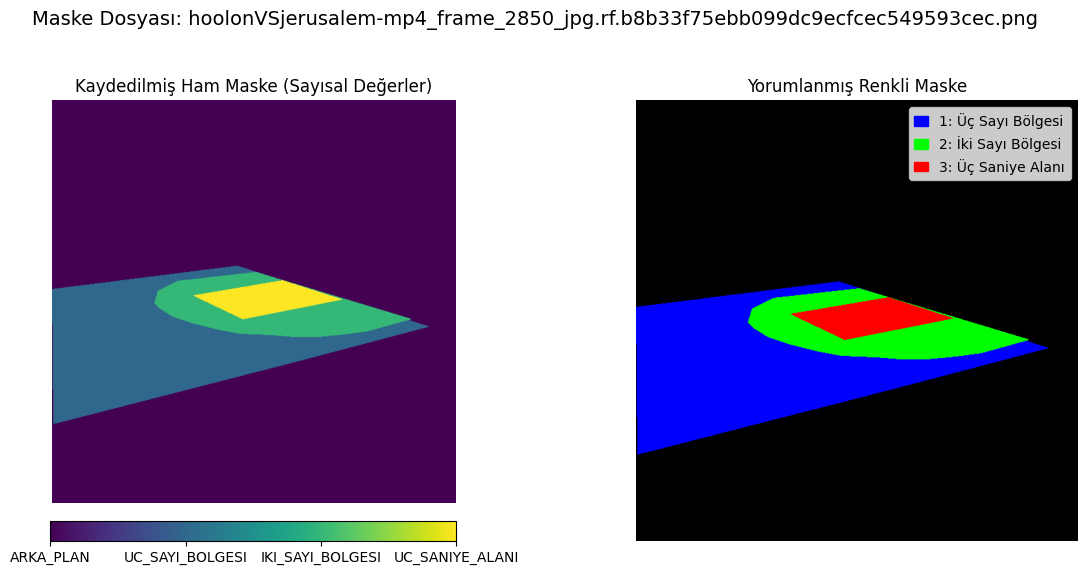

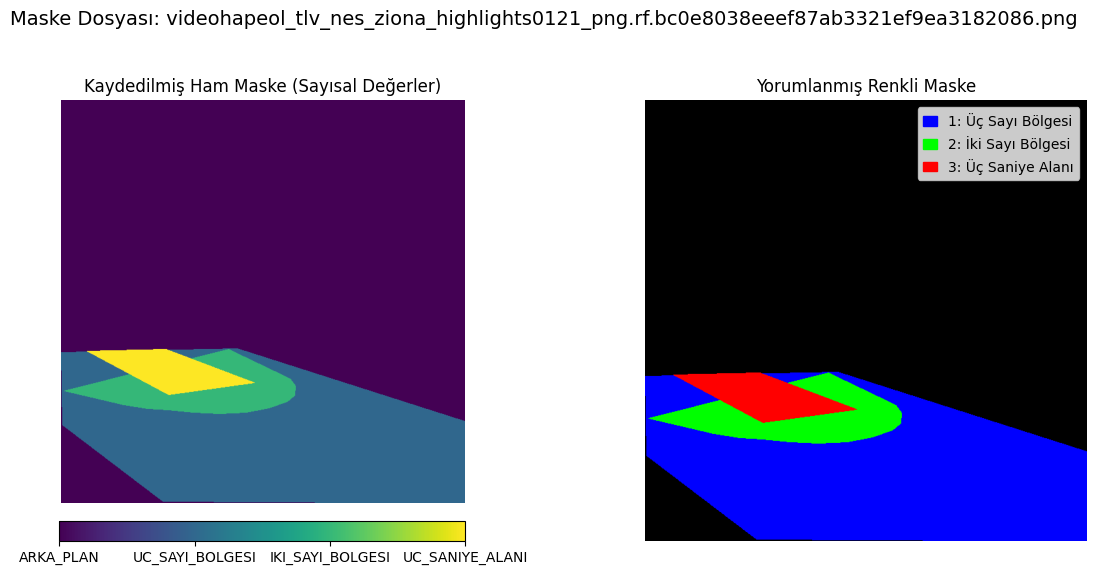

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# --- Adım 1: Ayarları Yapılandırma ---

# Kaydedilmiş maskelerin bulunduğu klasör
SAVED_MASKS_DIR = './data/courtv2-3/test/masks'

# Görselleştirilecek rastgele örnek sayısı
NUM_SAMPLES_TO_VISUALIZE = 3

# --- Adım 2: Sınıf ve Renk Tanımlamalarını Tekrar Belirleme ---
# Bu, görselleştirmenin doğru etiketleri ve renkleri kullanması için gereklidir.

mask_class_ids = {
    "ARKA_PLAN": 0,
    "UC_SAYI_BOLGESI": 1,
    "IKI_SAYI_BOLGESI": 2,
    "UC_SANIYE_ALANI": 3
}

# Renkler (BGR formatında)
class_colors = {
    "ARKA_PLAN": [0, 0, 0],
    "UC_SAYI_BOLGESI": [255, 0, 0],   # Mavi
    "IKI_SAYI_BOLGESI": [0, 255, 0],   # Yeşil
    "UC_SANIYE_ALANI": [0, 0, 255]       # Kırmızı
}


# --- Adım 3: Maske Dosyalarını Bulma ve Seçme ---

# Klasörün var olup olmadığını kontrol et
if not os.path.isdir(SAVED_MASKS_DIR):
    print(f"HATA: '{SAVED_MASKS_DIR}' adında bir klasör bulunamadı. Lütfen önce maskeleri oluşturup kaydedin.")
    exit()

# Klasördeki tüm .png dosyalarını listele
mask_files = [f for f in os.listdir(SAVED_MASKS_DIR) if f.endswith('.png')]

if not mask_files:
    print(f"HATA: '{SAVED_MASKS_DIR}' klasöründe hiç .png uzantılı maske dosyası bulunamadı.")
    exit()

# Görselleştirmek için rastgele dosyalar seç
if len(mask_files) > NUM_SAMPLES_TO_VISUALIZE:
    selected_files = random.sample(mask_files, NUM_SAMPLES_TO_VISUALIZE)
else:
    selected_files = mask_files

print(f"'{SAVED_MASKS_DIR}' klasöründen {len(selected_files)} adet rastgele maske görselleştiriliyor...")


# --- Adım 4: Renklendirme Fonksiyonu ---

def colorize_loaded_mask(mask_array, color_map, id_map):
    # Boş bir renkli görüntü oluştur
    color_mask = np.zeros((mask_array.shape[0], mask_array.shape[1], 3), dtype=np.uint8)
    
    # Her bir class ID'si için ilgili pikselleri renklendir
    for class_name, class_id in id_map.items():
        if class_id != 0: # Arka planı atla
            color_mask[mask_array == class_id] = color_map[class_name]
            
    return color_mask


# --- Adım 5: Seçilen Maskeleri Yükleme ve Görselleştirme ---

for mask_filename in selected_files:
    # Maske dosyasının tam yolunu oluştur
    mask_path = os.path.join(SAVED_MASKS_DIR, mask_filename)

    # Maskeyi grayscale (tek kanal) olarak yükle
    # cv2.IMREAD_UNCHANGED veya cv2.IMREAD_GRAYSCALE kullanmak önemlidir.
    loaded_mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
    
    if loaded_mask is None:
        print(f"UYARI: '{mask_filename}' dosyası yüklenemedi, atlanıyor.")
        continue

    # Yüklenen maskeyi renklendir
    colorized_mask = colorize_loaded_mask(loaded_mask, class_colors, mask_class_ids)

    # Sonuçları Matplotlib ile göster
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Maske Dosyası: {mask_filename}", fontsize=14)

    # Sol Panel: Kaydedilmiş Ham Maske
    ax = axes[0]
    im = ax.imshow(loaded_mask, cmap='viridis')
    ax.set_title("Kaydedilmiş Ham Maske (Sayısal Değerler)")
    ax.axis('off')
    
    cbar = fig.colorbar(im, ax=ax, ticks=list(mask_class_ids.values()), orientation='horizontal', fraction=0.046, pad=0.04)
    cbar.set_ticklabels(list(mask_class_ids.keys()))

    # Sağ Panel: Yorumlanmış Renkli Maske
    ax = axes[1]
    ax.imshow(cv2.cvtColor(colorized_mask, cv2.COLOR_BGR2RGB))
    ax.set_title("Yorumlanmış Renkli Maske")
    ax.axis('off')
    
    patches = [plt.Rectangle((0,0),1,1, color=np.array(c[::-1])/255) for c in [class_colors['UC_SAYI_BOLGESI'], class_colors['IKI_SAYI_BOLGESI'], class_colors['UC_SANIYE_ALANI']]]
    ax.legend(patches, ['1: Üç Sayı Bölgesi', '2: İki Sayı Bölgesi', '3: Üç Saniye Alanı'], loc='best', handlelength=1)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [6]:
import torch
torch.__version__

'2.8.0+cu128'

In [7]:
import os
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
from PIL import Image


class BasketballCourtDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        # Dosya yollarını oluştur
        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.images[index].replace('.jpg', '.png'))

        # Görüntü ve maskeyi oku
        # Görüntü Renkli (BGR), Maske Siyah-Beyaz (Grayscale)
        image = Image.open(img_path,).convert("RGB") # OpenCV BGR okur, RGB'ye çevir
        image = np.array(image)
        mask = Image.open(mask_path).convert("L")
        mask = np.array(mask)

        # Maske piksellerini 0 ve 1 arasına getiriyoruz.
        # Siyah (0) arka plan, Beyaz (255) saha -> Siyah (0), Beyaz (1)
        mask[mask == 255.0] = 1.0

        # Veri artırma (augmentation) uygula
        if self.transform is not None:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]
        
        
        return image, mask.long()

In [8]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# --- AYARLAR ---
TRAIN_IMG_DIR = "data/courtv2/train/images/"
TRAIN_MASK_DIR = "data/courtv2/train/masks/"
VAL_IMG_DIR = "data/courtv2/valid/images/"
VAL_MASK_DIR = "data/courtv2/valid/masks/"
IMAGE_HEIGHT = 640 # Modelinize uygun bir boyut seçin
IMAGE_WIDTH = 640
BATCH_SIZE = 16
NUM_CLASSES = 4
# --- AYARLAR SONU ---

# Eğitim seti için veri artırma ve dönüşümler
train_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Rotate(limit=35, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0,
        ),
        ToTensorV2(), # NumPy array'i PyTorch tensörüne çevirir
    ],
)

# Doğrulama seti için sadece yeniden boyutlandırma ve normalize etme yeterli
val_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
)

# Dataset ve DataLoader'ları oluştur
train_dataset = BasketballCourtDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, train_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = BasketballCourtDataset(VAL_IMG_DIR, VAL_MASK_DIR, val_transforms)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
data, targets = next(iter(train_loader))
targets[targets == 1].shape

torch.Size([0])

In [4]:
import torch.optim as optim
import segmentation_models_pytorch as smp

# --- AYARLAR ---
LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# --- AYARLAR SONU ---

# Modeli oluştur
# encoder_name: Önceden eğitilmiş omurga modeli
# encoder_weights: 'imagenet' ağırlıklarını kullan
# classes=1: Sadece bir sınıfımız var (saha var veya yok)
# activation='sigmoid': Çıktıyı 0-1 aralığına sıkıştırmak için
model = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3, # RGB görüntü için 3 kanal
    classes=NUM_CLASSES,     # Sadece saha maskesi
    activation="softmax",
).to(DEVICE)

# Kayıp fonksiyonu ve Optimizasyon algoritması
# Dice Loss, segmentasyon görevlerinde IoU'yu optimize etmede çok başarılıdır.
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# Learning rate scheduler ekle
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
)

# Değerlendirme için metrik
# IoU (Intersection over Union), segmentasyon başarısını ölçen standart bir metriktir.
iou_metric = smp.metrics.iou_score

In [5]:
from tqdm import tqdm # İlerleme çubuğu için

# --- AYARLAR ---
NUM_EPOCHS = 50
# --- AYARLAR SONU ---

best_val_iou = 0.0 # En iyi IoU skorunu takip etmek için

for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

    # EĞİTİM AŞAMASI
    model.train() # Modeli eğitim moduna al
    train_loss = 0.0

    for batch_idx, (data, targets) in enumerate(tqdm(train_loader, desc="Training")):
        data = data.to(device=DEVICE, dtype=torch.float32)
        # Maskenin kanal boyutu eklenmeli: [N, H, W] -> [N, 1, H, W]
        targets = targets.to(device=DEVICE, dtype=torch.long)

        targets[targets == 2] = 1
        targets[targets == 3] = 2
        targets[targets == 4] = 3

        # İleri yayılım (forward pass)
        predictions = model(data)
        loss = loss_fn(predictions, targets)
        train_loss += loss.item()

        # Geri yayılım (backward pass)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = train_loss / len(train_loader)
    print(f"Average Training Loss: {avg_train_loss:.4f}")
    
    
    # DOĞRULAMA AŞAMASI
    model.eval()
    total_tp = torch.zeros(NUM_CLASSES).to(DEVICE)  # Her sınıf için ayrı TP sayısı
    total_fp = torch.zeros(NUM_CLASSES).to(DEVICE)
    total_fn = torch.zeros(NUM_CLASSES).to(DEVICE)
    total_tn = torch.zeros(NUM_CLASSES).to(DEVICE)

    with torch.no_grad():
        for data, targets in tqdm(val_loader, desc="Validation"):
            data = data.to(device=DEVICE, dtype=torch.float32)
            targets = targets.to(device=DEVICE, dtype=torch.long)

            preds_logits = model(data)
            preds_labels = torch.argmax(preds_logits, dim=1)
            
            # Her sınıf için metrik hesapla
            for class_idx in range(NUM_CLASSES):
                stats = smp.metrics.get_stats(
                    preds_labels == class_idx,
                    targets == class_idx,
                    mode='binary',
                    num_classes=1
                )
                tp, fp, fn, tn = stats
                
                total_tp[class_idx] += tp.sum()
                total_fp[class_idx] += fp.sum()
                total_fn[class_idx] += fn.sum()
                total_tn[class_idx] += tn.sum()

    # IoU'yu hesapla
    epoch_iou = smp.metrics.iou_score(
        total_tp, 
        total_fp, 
        total_fn, 
        total_tn, 
        reduction="macro"  # Tüm sınıfların ortalamasını al
    )

    print(f"Validation IoU Score: {epoch_iou:.4f}")
    
    scheduler.step(epoch_iou)


--- Epoch 1/50 ---


Training:   0%|          | 0/35 [00:29<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 100.00 MiB. GPU 0 has a total capacity of 6.00 GiB of which 0 bytes is free. Of the allocated memory 12.39 GiB is allocated by PyTorch, and 143.10 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

'cuda'

In [ ]:
import albumentations as A
imprt
# Test için sadece yeniden boyutlandırma ve normalizasyon transformu
test_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
)

# 1. Modeli yeniden oluştur
# Eğitimde hangi mimariyi kullandıysanız aynısını kullanmalısınız
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None, # Ağırlıkları kendimiz yükleyeceğiz
    in_channels=3,
    classes=1,
    activation="sigmoid",
).to(DEVICE)

# 2. Kaydedilmiş en iyi ağırlıkları yükle
model.load_state_dict(torch.load("./models/best_modelv2.pth", map_location=torch.device(DEVICE)))
model.to(DEVICE)
model.eval() # Modeli DEĞERLENDİRME moduna al (çok önemli!)

test_dataset = BasketballCourtDataset("./data/courtv2a/courtv2/test/images/", "./data/courtv2a/courtv2/test/masks/", transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

NameError: name 'smp' is not defined

In [21]:
from tqdm._tqdm import tqdm

print("\n--- TEST SETİ DEĞERLENDİRMESİ BAŞLADI ---")
total_tp = 0
total_fp = 0
total_fn = 0
total_tn = 0

with torch.no_grad():
    for data, targets in tqdm(test_loader, desc="Testing"):
        data = data.to(device=DEVICE, dtype=torch.float32)
        targets = targets.unsqueeze(1).to(device=DEVICE, dtype=torch.float32)
        
        preds = model(data)
        preds = (preds > 0.5).float()
        
        stats = smp.metrics.get_stats(preds, targets.long(), mode='binary', threshold=0.5)
        tp, fp, fn, tn = stats
        
        total_tp += tp.sum()
        total_fp += fp.sum()
        total_fn += fn.sum()
        total_tn += tn.sum()

test_iou = smp.metrics.iou_score(total_tp, total_fp, total_fn, total_tn, reduction="micro")

print(f"\n==========================================")
print(f"TEST SETİ SONUCU - IoU Skoru: {test_iou:.4f}")
print(f"==========================================")


--- TEST SETİ DEĞERLENDİRMESİ BAŞLADI ---


Testing: 100%|██████████| 2/2 [00:00<00:00,  3.48it/s]


TEST SETİ SONUCU - IoU Skoru: 0.9012


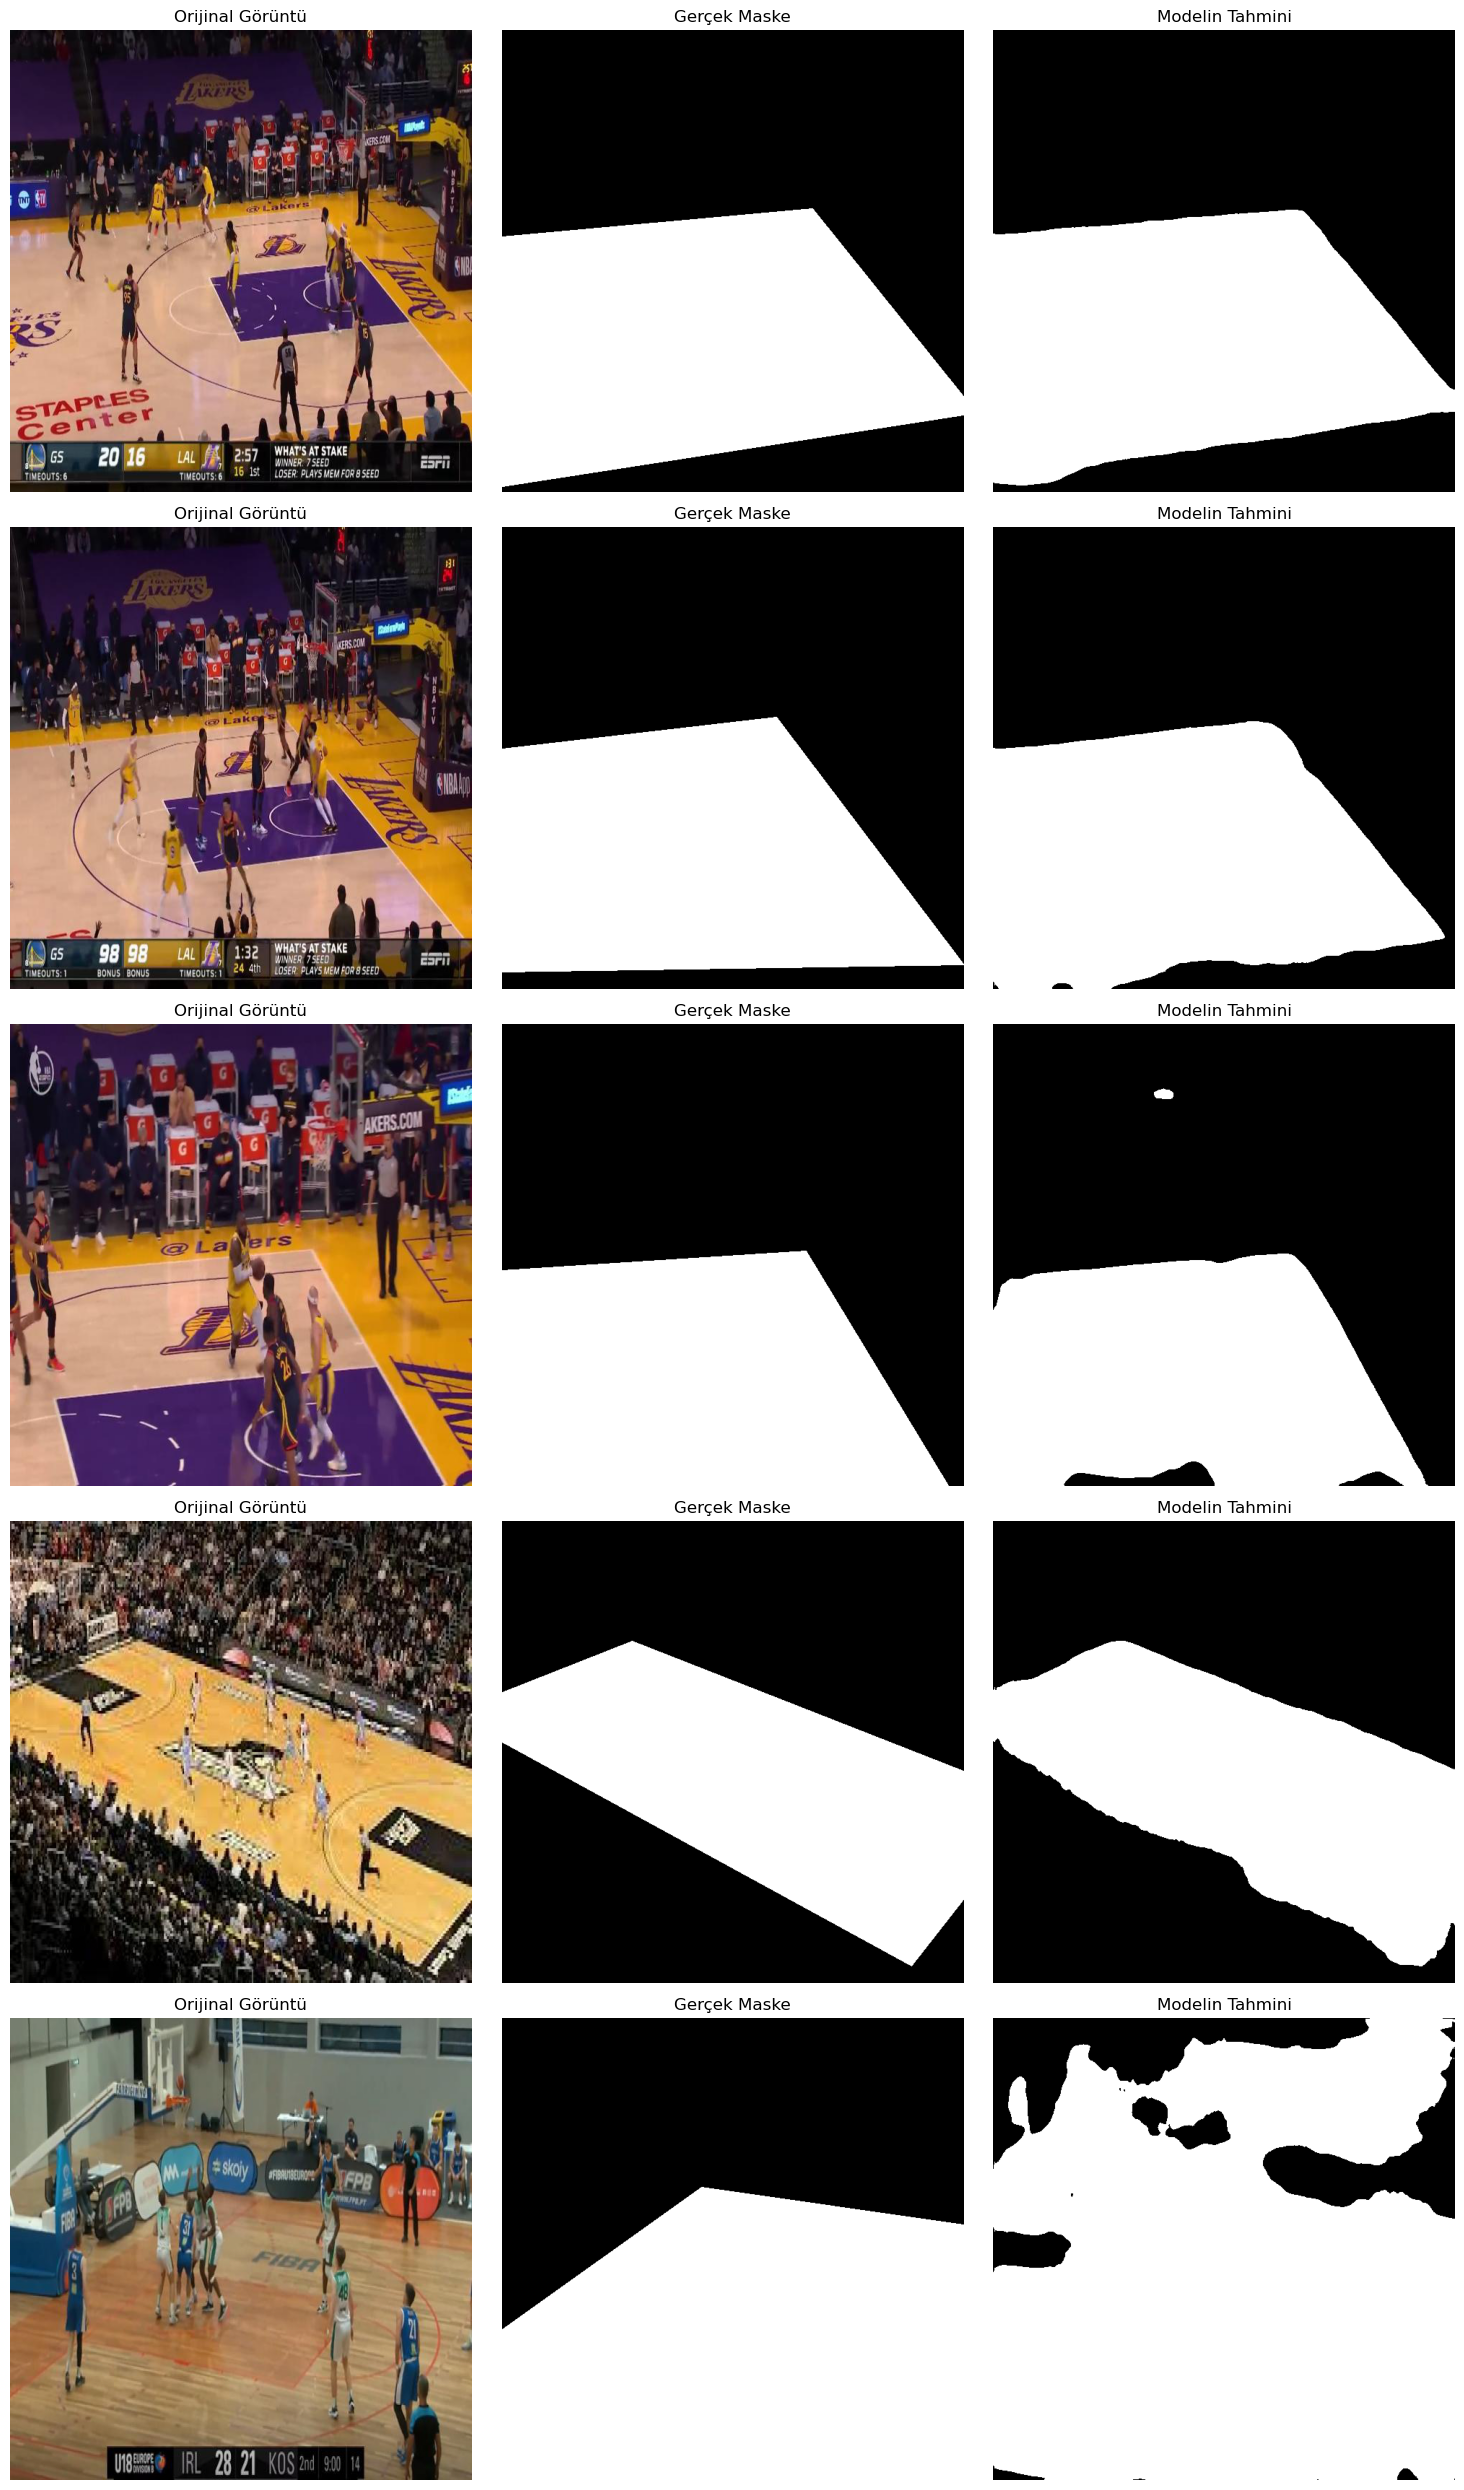

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_predictions(model, loader, device, num_images=5):
    """Test setinden birkaç örneği görselleştirir."""
    model.eval()
    
    images, masks = next(iter(loader))
    images = images.to(device)
    
    with torch.no_grad():
        preds = model(images)
        preds = (preds > 0.5).float()
        
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(15, 5 * num_images))
    for i in range(min(num_images, len(images))):
        plt.subplot(num_images, 3, i * 3 + 1)
        original_image = np.transpose(images[i], (1, 2, 0))
        plt.imshow(original_image)
        plt.title("Orijinal Görüntü")
        plt.axis("off")
        
        plt.subplot(num_images, 3, i * 3 + 2)
        true_mask = np.squeeze(masks[i])
        plt.imshow(true_mask, cmap='gray')
        plt.title("Gerçek Maske")
        plt.axis("off")
        
        plt.subplot(num_images, 3, i * 3 + 3)
        pred_mask = np.squeeze(preds[i])
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Modelin Tahmini")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Fonksiyonu çağırarak 5 örneği görselleştir
visualize_predictions(model, test_loader, DEVICE, num_images=5)

In [33]:
import torch
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# --- AYARLAR ---
# İşlemek istediğiniz videonun ve çıktı videosunun yollarını belirtin
VIDEO_INPUT_PATH = "court.mp4"
VIDEO_OUTPUT_PATH = "output_video.mp4"
MODEL_PATH = "best_model.pth"

# Model ve transform ayarları eğitimdekiyle aynı olmalı
IMAGE_HEIGHT = 640
IMAGE_WIDTH = 640
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# --- AYARLAR SONU ---

def process_video(model, device, video_path, output_path, transforms):
    """
    Bir videoyu kare kare işler, segmentasyon tahmini yapar ve sonuçları
    yeni bir videoya kaydeder.
    """
    # 1. Video okuyucuyu (capture) başlat
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Hata: {video_path} açılamadı.")
        return

    # 2. Video yazıcıyı (writer) ayarla
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # MP4 formatı için 'mp4v' codec'ini kullanıyoruz
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    print(f"Video işleniyor... Toplam Kare: {total_frames}, FPS: {fps}")

    model.eval() # Modeli değerlendirme moduna al

    # İlerleme çubuğu için tqdm kullan
    for _ in tqdm(range(total_frames), desc="Video İşleniyor"):
        ret, frame = cap.read()
        if not ret:
            break

        # 3. Kareyi modelin anlayacağı formata çevir
        # OpenCV BGR okur, biz RGB'ye çeviriyoruz
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Transformları uygula
        augmented = transforms(image=rgb_frame)
        input_tensor = augmented['image']
        
        # Batch boyutu ekle ve doğru cihaza gönder
        input_tensor = input_tensor.unsqueeze(0).to(device)
        
        # 4. Tahmin yap
        with torch.no_grad():
            pred_tensor = model(input_tensor)
            # Olasılıkları 0 veya 1'e çevir
            pred_mask = (pred_tensor > 0.5).squeeze().cpu().numpy().astype(np.uint8)

        # 5. Maskeyi görselleştirmek için renklendir
        # Maskeyi orijinal boyutuna geri getir
        pred_mask_resized = cv2.resize(pred_mask, (frame_width, frame_height), interpolation=cv2.INTER_NEAREST)
        
        # Renkli bir overlay oluştur (örneğin yeşil)
        overlay = np.zeros_like(frame, dtype=np.uint8)
        # Sadece basketbol sahası olan pikselleri yeşil yap
        overlay[pred_mask_resized == 1] = [0, 255, 0] # Yeşil renk (BGR formatında)

        # 6. Orijinal kare ile maskeyi birleştir (blend)
        # 0.6 şeffaflık değeri ile maskeyi ekle
        output_frame = cv2.addWeighted(frame, 1, overlay, 0.6, 0)
        
        # 7. Sonucu ekranda göster ve dosyaya yaz
        cv2.imshow('Basketbol Sahası Segmentasyonu', output_frame)
        out.write(output_frame)

        # 'q' tuşuna basılırsa çık
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # 8. Her şeyi serbest bırak
    print(f"İşlem tamamlandı. Sonuç '{output_path}' dosyasına kaydedildi.")
    cap.release()
    out.release()
    cv2.destroyAllWindows()


# --- ANA ÇALIŞTIRMA KISMI ---

if __name__ == "__main__":
    # Test için kullandığımız transformların aynısı
    video_transforms = A.Compose(
        [
            A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
            A.Normalize(
                mean=[0.0, 0.0, 0.0],
                std=[1.0, 1.0, 1.0],
                max_pixel_value=255.0,
            ),
            ToTensorV2(),
        ],
    )

    # Modeli oluştur ve eğitilmiş ağırlıkları yükle
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights=None,
        in_channels=3,
        classes=1,
        activation="sigmoid",
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))
    model.to(DEVICE)

    # Ana fonksiyonu çağır
    process_video(model, DEVICE, VIDEO_INPUT_PATH, VIDEO_OUTPUT_PATH, video_transforms)

Video işleniyor... Toplam Kare: 19095, FPS: 30


Video İşleniyor:   7%|▋         | 1350/19095 [00:56<12:19, 24.00it/s]


KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot

✅ Gerçek zamanlı maskeleme başlatıldı. Hücreyi durdurarak çıkabilirsin (Kernel → Interrupt).


TypeError: conv2d() received an invalid combination of arguments - got (numpy.ndarray, Parameter, NoneType, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


In [ ]:
import os
import json
import numpy as np
import cv2
from pycocotools.coco import COCO

def create_multiclass_masks_from_coco(data_dir):
    """
    COCO formatındaki veri setinden çok-sınıflı segmentasyon maskeleri oluşturur.
    Her sınıf farklı bir piksel değeri alır (1, 2, 3...).
    """
    annotation_file = os.path.join(data_dir, '_annotations.coco.json')
    if not os.path.exists(annotation_file):
        print(f"Uyarı: '{annotation_file}' bulunamadı. Bu klasör atlanıyor.")
        return

    masks_dir_path = os.path.join(data_dir, 'masks')
    os.makedirs(masks_dir_path, exist_ok=True)
    
    coco = COCO(annotation_file)
    
    # 1. Kategori ID'lerini yeni ve sıralı piksel değerlerine eşle
    # COCO ID'leri sıralı olmayabilir (örn: 4, 7, 12). Biz 1, 2, 3... kullanacağız.
    cat_ids = coco.getCatIds()
    cats = coco.loadCats(cat_ids)
    # Kategori adlarını ve yeni ID'leri yazdır
    print(f"'{data_dir}' içindeki sınıflar ve atanacak piksel değerleri:")
    category_map = {}
    for i, cat in enumerate(cats):
        # Yeni piksel değerini 1'den başlatıyoruz (0 arka plan için)
        pixel_value = i + 1
        category_map[cat['id']] = pixel_value
        print(f"  - Sınıf Adı: '{cat['name']}', Orjinal ID: {cat['id']} -> Yeni Piksel Değeri: {pixel_value}")
    
    img_ids = coco.getImgIds()
    images = coco.loadImgs(img_ids)
    
    print(f"'{data_dir}' içinde {len(images)} adet görüntü için maskeler oluşturuluyor...")
    
    for img_info in images:
        # Arka plan 0 olacak şekilde boş bir maske oluştur
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        ann_ids = coco.getAnnIds(imgIds=img_info['id'])
        anns = coco.loadAnns(ann_ids)
        
        for ann in anns:
            category_id = ann['category_id']
            # Eşlediğimiz yeni piksel değerini al
            pixel_value = category_map.get(category_id)
            
            if pixel_value is not None and 'segmentation' in ann:
                for seg in ann['segmentation']:
                    poly = np.array(seg, dtype=np.int32).reshape((-1, 2))
                    # Poligonu ilgili sınıfın piksel değeriyle doldur
                    cv2.fillPoly(mask, [poly], color=pixel_value)

        output_filename = os.path.splitext(img_info['file_name'])[0] + '.png'
        output_path = os.path.join(masks_dir_path, output_filename)
        cv2.imwrite(output_path, mask)

    print(f"Çok-sınıflı maskeler başarıyla '{masks_dir_path}' klasörüne kaydedildi.")

# --- KODU ÇALIŞTIRMA ---
DATASET_ROOT = './data/courtv2/'

for split in ['train', 'valid', 'test']:
    split_dir = os.path.join(DATASET_ROOT, split)
    if os.path.exists(split_dir):
        create_multiclass_masks_from_coco(split_dir)

Uyarı: '/../_annotations.coco.json' bulunamadı. Bu klasör atlanıyor.
Uyarı: '/../_annotations.coco.json' bulunamadı. Bu klasör atlanıyor.
Uyarı: '/../_annotations.coco.json' bulunamadı. Bu klasör atlanıyor.


In [12]:
import torch
import cv2
import numpy as np
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from tqdm import tqdm

# --- AYARLAR (Lütfen bu bölümü kendi dosya yollarınıza göre güncelleyin) ---

# 1. Model ve Veri Yolları
MODEL_PATH = "./models/best_modelv2.pth"  # Eğitimle kaydettiğiniz en iyi modelin yolu
TEST_IMAGE_DIR = "./data/courtv2a/courtv2/valid/images/"  # Test resimlerinizin olduğu klasör
TEST_MASK_DIR = "./data/courtv2a/courtv2/valid/masks/"    # Test maskelerinizin olduğu klasör (opsiyonel)
OUTPUT_DIR = "test_results/"                 # Sonuçların kaydedileceği klasör

# 2. Eğitimle Birebir Aynı Olması Gereken Model Parametreleri
ENCODER_NAME = "resnet34"  # Eğitimde kullandığınız encoder (örn: "resnet50")
NUM_CLASSES = 5            # Eğitimdeki sınıf sayısı (1 Arka Plan + 4 Sınıf)
IMAGE_HEIGHT = 640         # Eğitimdeki resim yüksekliği
IMAGE_WIDTH = 640          # Eğitimdeki resim genişliği

# 3. Görselleştirme Ayarları (Renkler BGR formatında)
# Bu sıralama, maske oluşturma script'indeki sıralama ile aynı olmalıdır.
CLASS_COLORS = [
    [0, 0, 0],       # 0: Arka Plan - Siyah
    [255, 0, 0],     # 1: 3ptline-freethrowline - Mavi
    [0, 255, 0],     # 2: court - Yeşil
    [0, 0, 255],     # 3: three_second_area - Kırmızı
    [255, 255, 0],   # 4: two_point_area - Camgöbeği
]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# --- AYARLAR SONU ---

def colorize_mask(mask, colors):
    """Tek kanallı sınıf maskesini, her sınıf için farklı bir renkle BGR formatına çevirir."""
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_idx in range(1, len(colors)): # Arka planı (0) atla
        color_mask[mask == class_idx] = colors[class_idx]
    return color_mask

def test_model_on_images():
    """Test klasöründeki görselleri işler ve sonuçları kaydeder."""
    # 1. Modeli, eğitimdeki mimarinin birebir aynısıyla oluştur
    print("Model yükleniyor...")
    model = smp.Unet(
        encoder_name=ENCODER_NAME,
        encoder_weights=None,
        in_channels=3,
        classes=NUM_CLASSES,
        activation=None,
    )
    model.load_state_dict(torch.load(MODEL_PATH, map_location=torch.device(DEVICE)))
    model.to(DEVICE)
    model.eval() # Modeli değerlendirme moduna al

    # 2. Test için gerekli transformları tanımla (eğitimdeki validation transform'u gibi)
    transforms = A.Compose([
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Normalize(mean=[0.0, 0.0, 0.0], std=[1.0, 1.0, 1.0], max_pixel_value=255.0),
        ToTensorV2(),
    ])

    # 3. Sonuçların kaydedileceği klasörü oluştur
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Sonuçlar '{OUTPUT_DIR}' klasörüne kaydedilecek.")

    image_files = os.listdir(TEST_IMAGE_DIR)
    
    for image_name in tqdm(image_files, desc="Test Görselleri İşleniyor"):
        image_path = os.path.join(TEST_IMAGE_DIR, image_name)
        
        # Orijinal resmi oku
        original_image = cv2.imread(image_path)
        if original_image is None:
            continue
            
        # Resmi modele uygun hale getir
        image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
        augmented = transforms(image=image_rgb)
        input_tensor = augmented['image'].unsqueeze(0).to(DEVICE)

        # Tahmin yap
        with torch.no_grad():
            pred_logits = model(input_tensor)
            pred_mask = torch.argmax(pred_logits, dim=1).squeeze().cpu().numpy().astype(np.uint8)

        # Tahmin maskesini orijinal boyutuna geri getir ve renklendir
        pred_mask_resized = cv2.resize(pred_mask, (original_image.shape[1], original_image.shape[0]), interpolation=cv2.INTER_NEAREST)
        pred_mask_colorized = colorize_mask(pred_mask_resized, CLASS_COLORS)
        
        # Gerçek maskeyi oku ve renklendir (eğer varsa)
        mask_name = os.path.splitext(image_name)[0] + '.png'
        mask_path = os.path.join(TEST_MASK_DIR, mask_name)
        if os.path.exists(mask_path):
            true_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            true_mask_colorized = colorize_mask(true_mask, CLASS_COLORS)
        else:
            # Gerçek maske yoksa, siyah bir alan oluştur
            true_mask_colorized = np.zeros_like(original_image)
            
        # Sonuçları birleştirmek için maskelere başlık ekle
        cv2.putText(true_mask_colorized, "Gercek Maske", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
        cv2.putText(pred_mask_colorized, "Modelin Tahmini", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)

        # Orijinal, gerçek ve tahmin görüntülerini yan yana birleştir
        combined_image = np.hstack([original_image, true_mask_colorized, pred_mask_colorized])
        
        # Sonuç görselini kaydet
        output_path = os.path.join(OUTPUT_DIR, image_name)
        cv2.imwrite(output_path, combined_image)

    print("\nTüm test görselleri işlendi ve kaydedildi.")


if __name__ == "__main__":
    test_model_on_images()

Model yükleniyor...
Sonuçlar 'test_results/' klasörüne kaydedilecek.


Test Görselleri İşleniyor: 100%|██████████| 50/50 [00:02<00:00, 18.36it/s]


Tüm test görselleri işlendi ve kaydedildi.


In [ ]:
import os
import json
import numpy as np
import cv2
from tqdm import tqdm

# --- AYARLAR ---
# JSON dosyasının yolu
JSON_FILE_PATH = r"C:\Users\524ha\Desktop\Resources\BasketballGameTracker\data\courtv2-3\train\_annotations.coco.json"

# ⭐️ ÖNEMLİ: Görüntülerin bulunduğu klasörün yolu.
# JSON dosyasının bulunduğu klasördeki 'images' alt klasörünü varsayıyoruz.
# Eğer yapı farklıysa, burayı manuel olarak düzeltin.
IMAGES_DIR = os.path.join(os.path.dirname(JSON_FILE_PATH), 'images')

# Oluşturulacak maskelerin kaydedileceği ÇIKTI klasörü
OUTPUT_MASKS_DIR = './data/courtv2-3/masks'
# --- AYARLAR SONU ---


# --- HİYERARŞİ VE SINIF TANIMLAMALARI ---
mask_class_ids = {
    "ARKA_PLAN": 0,
    "UC_SAYI_BOLGESI": 1,
    "IKI_SAYI_BOLGESI": 2,
    "UC_SANIYE_ALANI": 3
}

category_name_to_mask_id = {
    'basketball-court': mask_class_ids['UC_SAYI_BOLGESI'],
    'three point line': mask_class_ids['IKI_SAYI_BOLGESI'],
    'Paint': mask_class_ids['UC_SANIYE_ALANI']
}

drawing_order_by_name = ['basketball-court', 'three point line', 'Paint']

# Bir verinin "iyi" sayılması için MUTLAKA içermesi gereken kategori adları
REQUIRED_CATEGORIES = {'basketball-court', 'three point line', 'Paint'}
# --- HİYERARŞİ SONU ---


def create_mask_from_coco(image_info, annotations, categories_map):
    height, width = image_info['height'], image_info['width']
    mask = np.full((height, width), mask_class_ids["ARKA_PLAN"], dtype=np.uint8)

    annotations_by_name = {name: [] for name in drawing_order_by_name}
    for ann in annotations:
        category_name = categories_map.get(ann['category_id'])
        if category_name in annotations_by_name:
            annotations_by_name[category_name].append(ann)
            
    for category_name in drawing_order_by_name:
        mask_id_to_paint = category_name_to_mask_id[category_name]
        
        for ann in annotations_by_name[category_name]:
            for seg in ann['segmentation']:
                polygon = np.array(seg, dtype=np.int32).reshape((-1, 1, 2))
                cv2.fillPoly(mask, [polygon], mask_id_to_paint)
                
    return mask

# --- ANA ÇALIŞTIRMA KISMI (SİLME ÖZELLİĞİ İLE) ---
if __name__ == "__main__":
    os.makedirs(OUTPUT_MASKS_DIR, exist_ok=True)
    
    print("JSON dosyası okunuyor...")
    with open(JSON_FILE_PATH, 'r') as f:
        coco_data = json.load(f)

    categories_map = {cat['id']: cat['name'] for cat in coco_data['categories']}

    annotations_by_image_id = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        if image_id not in annotations_by_image_id:
            annotations_by_image_id[image_id] = []
        annotations_by_image_id[image_id].append(ann)

    print(f"Toplam {len(coco_data['images'])} adet görüntü kontrol edilecek.")
    
    # Silinecek dosyaları ve oluşturulacakları tutmak için listeler
    images_to_delete = []
    valid_images_info = []

    # 1. Adım: Veri setini analiz et ve dosyaları sınıflandır
    for image_info in tqdm(coco_data['images'], desc="Görüntüler Analiz Ediliyor"):
        image_id = image_info['id']
        annotations = annotations_by_image_id.get(image_id, [])

        if not annotations:
            images_to_delete.append(image_info['file_name'])
            continue
        
        image_categories = {categories_map.get(ann['category_id']) for ann in annotations}
        
        if not REQUIRED_CATEGORIES.issubset(image_categories):
            # Eksik etiketli: Silinecekler listesine ekle
            images_to_delete.append(image_info['file_name'])
        else:
            # Tam etiketli: İşlenecekler listesine ekle
            valid_images_info.append(image_info)

    # 2. Adım: Kullanıcıya rapor ver ve onay al
    print("\n--- Analiz Tamamlandı ---")
    print(f"Maskesi oluşturulacak geçerli resim sayısı: {len(valid_images_info)}")
    print(f"Eksik etiket nedeniyle silinecek resim sayısı: {len(images_to_delete)}")
    
    if images_to_delete:
        print("\nSilinecek bazı resimler:")
        for fname in images_to_delete[:5]: # İlk 5 tanesini örnek olarak göster
            print(f" - {fname}")
        
        user_input = input(f"\nToplam {len(images_to_delete)} adet resim dosyası '{IMAGES_DIR}' klasöründen KALICI olarak silinecek. Onaylıyor musunuz? (evet/hayır): ")

        if user_input.lower() in ['evet', 'e', 'yes', 'y']:
            # 3. Adım: Onay verilirse dosyaları sil
            print("Silme işlemi başlıyor...")
            deleted_count = 0
            for filename in tqdm(images_to_delete, desc="Resimler Siliniyor"):
                file_path = os.path.join(IMAGES_DIR, filename)
                try:
                    if os.path.exists(file_path):
                        os.remove(file_path)
                        deleted_count += 1
                except OSError as e:
                    print(f"Hata: {file_path} silinemedi. - {e}")
            print(f"{deleted_count} adet resim dosyası silindi.")
        else:
            print("İşlem kullanıcı tarafından iptal edildi. Hiçbir dosya silinmedi ve maske oluşturulmayacak.")
            exit()
    
    # 4. Adım: Sadece geçerli resimler için maskeleri oluştur
    if valid_images_info:
        print("\nGeçerli resimler için maskeler oluşturuluyor...")
        for image_info in tqdm(valid_images_info, desc="Maskeler Oluşturuluyor"):
            image_id = image_info['id']
            annotations = annotations_by_image_id.get(image_id, [])
            mask = create_mask_from_coco(image_info, annotations, categories_map)
            
            base_name, _ = os.path.splitext(image_info['file_name'])
            output_filename = base_name + '.png'
            output_path = os.path.join(OUTPUT_MASKS_DIR, output_filename)
            
            cv2.imwrite(output_path, mask)

    print("\n--- İşlem Tamamlandı! ---")
    print(f"Başarıyla oluşturulan maske sayısı: {len(valid_images_info)}")
    print(f"Tüm oluşturulan maskeler '{OUTPUT_MASKS_DIR}' klasörüne kaydedildi.")

JSON dosyası okunuyor...
Toplam 136 adet görüntü kontrol edilecek.


Görüntüler Analiz Ediliyor: 100%|██████████| 136/136 [00:00<?, ?it/s]


--- Analiz Tamamlandı ---
Maskesi oluşturulacak geçerli resim sayısı: 15
Eksik etiket nedeniyle silinecek resim sayısı: 121

Silinecek bazı resimler:
 - hoolonVSjerusalem-mp4_frame_6450_jpg.rf.11fca202ae997a96ff1fbcdc013ae2ae.jpg
 - hoolonVSjerusalem-mp4_frame_5250_jpg.rf.060f87d7e749d7b19a6200cd6572e16c.jpg
 - Partizan-Zvezda-_-Round-5-Highlights-_-2023-24-Turkish-Airlines-EuroLeague-1-mp4_frame_5025_jpg.rf.199e5049caa4ebc64b6262982fbe13e1.jpg
 - videokai_rapaaport_hapoel_tlv0041_png.rf.178bb10c42073c9f56a0d494d7decd40.jpg
 - hapeltelavivVSjerusalem-mp4_frame_13425_jpg.rf.2101d1897030bbbf58b7f532d3fb874b.jpg


Silme işlemi başlıyor...


Resimler Siliniyor: 100%|██████████| 121/121 [00:00<00:00, 1159.75it/s]


121 adet resim dosyası silindi.

Geçerli resimler için maskeler oluşturuluyor...


Maskeler Oluşturuluyor: 100%|██████████| 15/15 [00:00<00:00, 855.90it/s]


--- İşlem Tamamlandı! ---
Başarıyla oluşturulan maske sayısı: 15
Tüm oluşturulan maskeler 'yeni_dataset_masks' klasörüne kaydedildi.
